In [1]:
import torchvision
import torch
import numpy as np
import os
import PIL.Image
import time
import copy
import seaborn as sn
import pandas as pd
import sklearn.metrics
from matplotlib import pyplot as plt
from math import ceil

In [2]:
class OstVisDataset(torch.utils.data.Dataset):
    def __init__(self, roots, transforms, subset, label_map, exclude_subfolders = None, split = (.6,.2,.2)):
        # list of root folders
        self.roots = roots

        # list of subfolders to exclude from sampling (e.g. if you only want control_well 1 and adipogenic differentiation)
        self.exclude_subfolders = exclude_subfolders

        # torchvision composed transforms
        self.transforms = transforms

        # dict mapping subfolder names to labels
        self.label_map = label_map

        # getting files
        self.enumerated_files = self.depthwise_enumerate(subset,split)

    def depthwise_enumerate(self, subset, split): 
        all_files = []
        # for each root folder
        for i in self.roots:
            # get subfolders
            folders = [f for f in os.listdir(i) if '.' not in f]
            
            if self.exclude_subfolders:
                folders = [f for f in folders if f.lower() not in self.exclude_subfolders]

            for j in folders:
                # get files from folders
                files = [i + j + '/' + f for f in os.listdir(i + j) if '.tif' in f]

                # copy files list
                files_copy = files.copy()

                # calculate sample size then select the proper subset
                train_size = ceil(len(files) * split[0])
                
                if subset == 'train':
                    upper_bound = train_size
                    files = files_copy[:upper_bound]
                elif subset == 'valid': 
                    lower_bound = train_size
                    upper_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:upper_bound]
                else:
                    lower_bound = train_size + ceil(len(files) * split[1])
                    files = files_copy[lower_bound:]
                
                # extend all files list by the file list for subfolder j
                all_files.extend(files)
        
        # return flat list of files
        return all_files
    
    def __len__(self):
        return len(self.enumerated_files)
    
    def __getitem__(self, idx):
        # check type
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        # get image at position idx in enumerated list
        image_path = self.enumerated_files[idx]
        image = PIL.Image.open(image_path).convert('RGB')
        
        # apply tranforms
        image = self.transforms(image)
        
        # separate subfolder name from path
        image_path_parts = image_path.split('/')

        # determine label
        label = self.label_map[image_path_parts[1].lower()]
        
        # return ((path, image), output) pair We will use path to track accuracy for each class: 7 day, 10 day, etc
        return ((image_path_parts[0], image), label)

In [3]:
def load_model(device):
    model_ft = torchvision.models.inception_v3(weights=torchvision.models.Inception_V3_Weights.IMAGENET1K_V1)
    num_ftrs = model_ft.fc.in_features
    # Here the size of each output sample is set to 2.
    # Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
    model_ft.fc = torch.nn.Linear(num_ftrs, 3)

    model_ft = model_ft.to(device)

    criterion = torch.nn.CrossEntropyLoss()

    # Observe that all parameters are being optimized
    optimizer_ft = torch.optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

    # Decay LR by a factor of 0.1 every 7 epochs
    exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
    return model_ft, criterion, exp_lr_scheduler, optimizer_ft

def train_model(model, criterion, optimizer, scheduler, device, dataloaders, dataset_sizes, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_epoch_accuracies = []
    val_epoch_accuracies = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)


        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0


            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs[1].to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    if phase == 'train':
                        outputs = outputs.logits
                    #print("outputs", outputs)
                    _, preds = torch.max(outputs, 1)
                    #print("preds", preds)
                    loss = criterion(outputs, labels)
                    #print(preds)
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_epoch_accuracies.append(float(epoch_acc))
            if phase == 'valid':
                val_epoch_accuracies.append(float(epoch_acc))
                
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best train acc: {best_acc:4f}')
    plt.plot([i + 1 for i in range(num_epochs)], train_epoch_accuracies, label='Train')
    plt.plot([i + 1 for i in range(num_epochs)], val_epoch_accuracies, label = 'Validation')
    plt.legend()
    plt.xlabel('Epoch', fontname='Arial', annot_kws={'fontsize' : 12})
    plt.ylabel('Accuracy', fontname='Arial', annot_kws={'fontsize' : 12})
    plt.show()

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [4]:
# initial construction of torch Dataset object
split_names = ['train', 'valid', 'test']
roots = ['2.28/', '3.3/', '3.6/', 'ZOE_ALL/', '1day.4.13/', '2day.4.14/', '3day.4.15/', '5day.4.17/']
label_map = {
    'control_well 1': 0,
    'adipogenic differentiation' : 1,
    'osteogenic differentiation' : 2,
    'control' : 0,
    'adi-well-1' : 1,
    'adi-well-2' : 1,
    'ctrl-well-1' : 0,
    'ctrl-well-2' : 0,
    'ost-well-1' : 2,
    'ost-well-2' : 2,
    'osteogenic' : 2,
    'adi' : 1,
    'crl' : 0,
    'ost' : 2
}

data_transforms = {
    'train': torchvision.transforms.Compose([
        torchvision.transforms.Resize(342),
        torchvision.transforms.RandomResizedCrop(299),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': torchvision.transforms.Compose([
        torchvision.transforms.Resize(342),
        torchvision.transforms.CenterCrop(299),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': torchvision.transforms.Compose([
        torchvision.transforms.Resize(342),
        torchvision.transforms.CenterCrop(299),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}


datasets = {split: OstVisDataset(roots= roots,
                      transforms= data_transforms[split],
                      subset= split,
                      label_map = label_map,
                      exclude_subfolders=['split', 'ost+adi-well-1', 'ost+adi-well-2', 'adipogenic + osteogenic', 'osteogenic + adipogenic']) 
                      for split in split_names
            }

for i in datasets['train'].enumerated_files:
    if i in datasets['valid'].enumerated_files:
        print('Duplicate Found: ', i)

for i in datasets['valid'].enumerated_files:
    if i in datasets['train'].enumerated_files or i in datasets['test'].enumerated_files:
        print('Duplicate Found: ', i)


# constructing dataloaders
dataloaders = {split : torch.utils.data.DataLoader(datasets[split], shuffle=True, batch_size=128, num_workers=0) for split in split_names}

# getting lens
dataset_sizes = {split : len(datasets[split]) for split in split_names}
print(dataset_sizes)

# constructing device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# load model
model_ft, criterion, exp_lr_scheduler, optimizer_ft = load_model(device)

print('Train files:', datasets['train'].enumerated_files)
print('Validation files:', datasets['valid'].enumerated_files)
print('Testing files:', datasets['test'].enumerated_files)

{'train': 1407, 'valid': 473, 'test': 456}
Train files: ['2.28/adipogenic differentiation/0228-pl2-adi-w1-df-1.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-10.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-11.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-12.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-13.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-14.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-15.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-16.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-17.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-18.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-19.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-2.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-20.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-21.tif', '2.28/adipogenic differentiation/0228-pl2-adi-w1-df-22.tif', '2.28/adipogenic differentiati

Epoch 0/29
----------
train Loss: 1.0854 Acc: 0.4030
valid Loss: 1.0257 Acc: 0.5603

Epoch 1/29
----------
train Loss: 0.9480 Acc: 0.6055
valid Loss: 0.8815 Acc: 0.7357

Epoch 2/29
----------
train Loss: 0.7930 Acc: 0.7498
valid Loss: 0.7366 Acc: 0.8055

Epoch 3/29
----------
train Loss: 0.6435 Acc: 0.8124
valid Loss: 0.5794 Acc: 0.8774

Epoch 4/29
----------
train Loss: 0.5027 Acc: 0.8600
valid Loss: 0.5242 Acc: 0.8774

Epoch 5/29
----------
train Loss: 0.4022 Acc: 0.8813
valid Loss: 0.3428 Acc: 0.9133

Epoch 6/29
----------
train Loss: 0.3048 Acc: 0.9183
valid Loss: 0.2970 Acc: 0.9027

Epoch 7/29
----------
train Loss: 0.2800 Acc: 0.9225
valid Loss: 0.2619 Acc: 0.9175

Epoch 8/29
----------
train Loss: 0.2890 Acc: 0.9033
valid Loss: 0.2874 Acc: 0.9091

Epoch 9/29
----------
train Loss: 0.2694 Acc: 0.9318
valid Loss: 0.2725 Acc: 0.9175

Epoch 10/29
----------
train Loss: 0.2693 Acc: 0.9119
valid Loss: 0.2566 Acc: 0.9281

Epoch 11/29
----------
train Loss: 0.2632 Acc: 0.9289
valid Loss

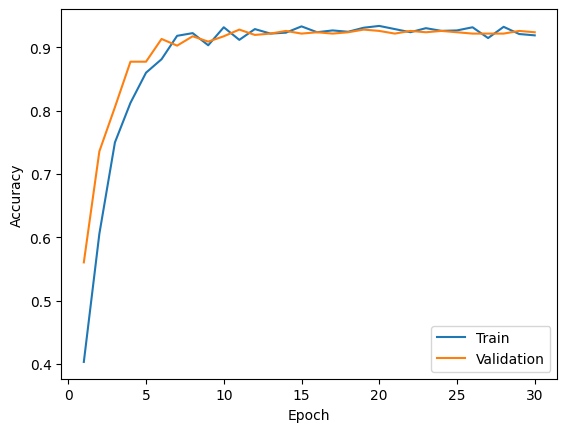

In [5]:
# train model
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,device, dataloaders, dataset_sizes,
                       num_epochs=30)

In [6]:
# only run this after training
torch.save(model_ft.state_dict(), 'OCNN_Multiclass_all_days_State_Dict_InceptionV3')

In [5]:
# load model from dict
model_ft.load_state_dict(torch.load('OCNN_Multiclass_all_days_State_Dict_InceptionV3'))

model_ft.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [6]:
true = []
pred = []
pred_probs = []

# making predictions
for i in dataloaders['test']:
    true.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]])))
    evals = model_ft(i[0][1])
    pred.extend([int(torch.argmax(j)) for j in evals])
    pred_probs.extend([torch.softmax(j, 0).detach().numpy() for j in evals])

# separating class label from filename 
true_numeric = [i[1] for i in true]

# overall metrics
print('Overall Accuracy: ', sklearn.metrics.accuracy_score(true_numeric, pred))
print('Overall One vs Rest AUC: ', sklearn.metrics.roc_auc_score(true_numeric, pred_probs, multi_class='ovr', average='weighted'))

Overall Accuracy:  0.9342105263157895
Overall One vs Rest AUC:  0.9899336166418979


<Axes: >

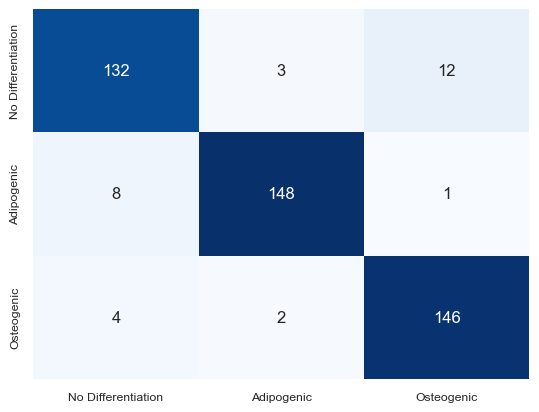

In [7]:
# labels for visual
class_names = ['No Differentiation', 'Adipogenic', 'Osteogenic']

# numeric confusion matrix
confusion_matrix = sklearn.metrics.confusion_matrix(true_numeric, pred)

# convert to df and make fancy confusion matrix
confusion_matrix_df = pd.DataFrame(confusion_matrix, index = class_names, columns = class_names)

sn.set(font_scale = .8)
sn.heatmap(confusion_matrix_df, annot=True, fmt='g', cbar=False, cmap='Blues', annot_kws={'fontsize' : 12})

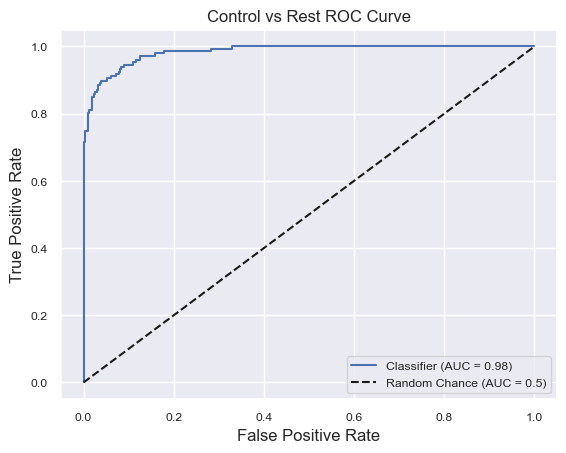

In [11]:
# Control vs Rest roc curve
control_vs_rest_true = [1 if i == 0 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(control_vs_rest_true, np.array(pred_probs)[:,0])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Control vs Rest ROC Curve', fontname='Arial', fontsize=12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize=12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize=12)
plt.legend()

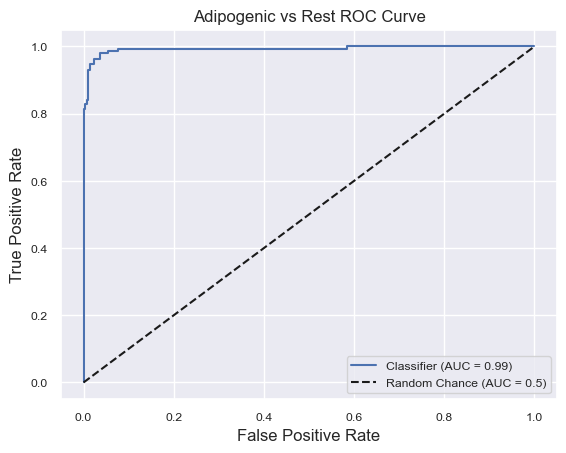

In [12]:
# Control vs Rest roc curve
adi_vs_rest_true = [1 if i == 1 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(adi_vs_rest_true, np.array(pred_probs)[:,1])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Adipogenic vs Rest ROC Curve', fontname='Arial', fontsize=12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize=12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize=12)
plt.legend()

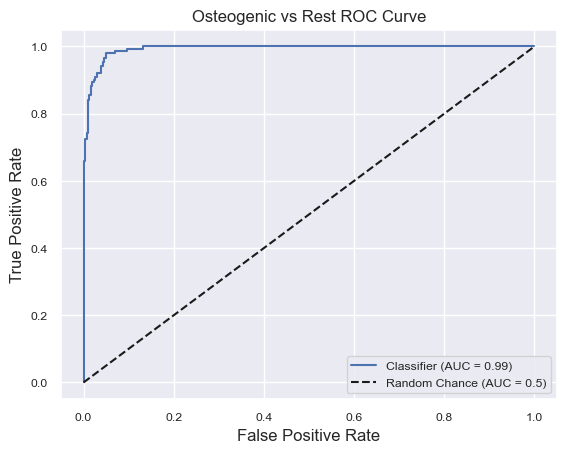

In [13]:
# Ost vs Rest roc curve
osteo_vs_rest_true = [1 if i == 2 else 0 for i in true_numeric]
sklearn.metrics.RocCurveDisplay.from_predictions(osteo_vs_rest_true, np.array(pred_probs)[:,2])
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5)')
plt.title('Osteogenic vs Rest ROC Curve', fontname='Arial', fontsize=12)
plt.xlabel('False Positive Rate', fontname='Arial', fontsize=12)
plt.ylabel('True Positive Rate', fontname='Arial', fontsize=12)
plt.legend()

In [16]:
# computing metrics by class

all = []

for i in zip(true, pred, pred_probs):
    # basically flattening the true and pred class. i[0][0] is filename, i[0][1] is true class, i[1] is prediction
    all.append((i[0][0], i[0][1], i[1], i[2]))

# convert to dataframe for easy slicing
all_preds_and_labels = pd.DataFrame(all, columns=['File Group', 'True Class', 'Prediction', 'Predicted Probs'])
metrics_dict = dict()

#print(all_preds_and_labels)

# compute metrics for each filename
for i in set(all_preds_and_labels['File Group']):
    slice = all_preds_and_labels[all_preds_and_labels['File Group'] == i]
    metrics_dict['{} Accuracy'.format(i)] = sklearn.metrics.accuracy_score(np.array(slice['True Class']), np.array(slice['Prediction']))
    metrics_dict['{} Overall One vs Rest AUC'.format(i)] = sklearn.metrics.roc_auc_score(slice['True Class'], [j for j in slice['Predicted Probs']], multi_class='ovr', labels=[0, 1, 2])

for i in metrics_dict.items():
    print(i)

('3.6 Accuracy', 1.0)
('3.6 Overall One vs Rest AUC', 1.0)
('ZOE_ALL Accuracy', 0.9322033898305084)
('ZOE_ALL Overall One vs Rest AUC', 0.9654183535762483)
('1day.4.13 Accuracy', 0.9473684210526315)
('1day.4.13 Overall One vs Rest AUC', 0.9935364727608494)
('3day.4.15 Accuracy', 0.8305084745762712)
('3day.4.15 Overall One vs Rest AUC', 0.9768556005398111)
('3.3 Accuracy', 1.0)
('3.3 Overall One vs Rest AUC', 1.0)
('5day.4.17 Accuracy', 0.8333333333333334)
('5day.4.17 Overall One vs Rest AUC', 0.9666666666666667)
('2.28 Accuracy', 0.9649122807017544)
('2.28 Overall One vs Rest AUC', 1.0)
('2day.4.14 Accuracy', 0.9830508474576272)
('2day.4.14 Overall One vs Rest AUC', 0.9978295096716149)


In [ ]:
true_train = []

for i in dataloaders['train']:
    true_train.extend(list(zip([j for j in i[0][0]], [int(j) for j in i[1]], [j for j in range(len(i[1]))])))
print(true_train)
all_train_labels = pd.DataFrame(true_train, columns=['File Group', 'True Class', 'ID'])

[('2day.4.14', 1, 0), ('5day.4.17', 2, 1), ('3.3', 0, 2), ('5day.4.17', 1, 3), ('3day.4.15', 1, 4), ('2day.4.14', 1, 5), ('3.3', 3, 6), ('ZOE_ALL', 2, 7), ('ZOE_ALL', 0, 8), ('2.28', 0, 9), ('3.6', 0, 10), ('2day.4.14', 2, 11), ('3day.4.15', 1, 12), ('2day.4.14', 1, 13), ('3.3', 1, 14), ('2.28', 0, 15), ('2day.4.14', 0, 16), ('2.28', 1, 17), ('ZOE_ALL', 3, 18), ('3.3', 3, 19), ('3.3', 1, 20), ('ZOE_ALL', 0, 21), ('3day.4.15', 0, 22), ('ZOE_ALL', 0, 23), ('3.6', 2, 24), ('1day.4.13', 0, 25), ('2.28', 2, 26), ('ZOE_ALL', 2, 27), ('1day.4.13', 1, 28), ('1day.4.13', 0, 29), ('3day.4.15', 1, 30), ('2.28', 1, 31), ('ZOE_ALL', 3, 32), ('2.28', 2, 33), ('2.28', 1, 34), ('2.28', 1, 35), ('ZOE_ALL', 0, 36), ('3.3', 0, 37), ('5day.4.17', 0, 38), ('3.3', 2, 39), ('1day.4.13', 0, 40), ('3.3', 2, 41), ('3day.4.15', 1, 42), ('3.3', 3, 43), ('ZOE_ALL', 1, 44), ('2.28', 0, 45), ('3.6', 1, 46), ('1day.4.13', 1, 47), ('3day.4.15', 2, 48), ('2.28', 2, 49), ('2.28', 0, 50), ('3.3', 3, 51), ('5day.4.17', 1,

In [ ]:
test_label_counts = all_preds_and_labels.groupby(['True Class', 'File Group']).count()
print(test_label_counts)

                       Prediction  Predicted Probs
True Class File Group                             
0          1day.4.13           19               19
           2.28                20               20
           2day.4.14           19               19
           3.3                 10               10
           3.6                 19               19
           3day.4.15           20               20
           5day.4.17           20               20
           ZOE_ALL             20               20
1          1day.4.13           19               19
           2.28                18               18
           2day.4.14           20               20
           3.3                 20               20
           3.6                 20               20
           3day.4.15           20               20
           5day.4.17           20               20
           ZOE_ALL             20               20
2          1day.4.13           19               19
           2.28                

In [ ]:
train_label_counts = all_train_labels.groupby(['True Class', 'File Group']).count()
print(train_label_counts)

                       ID
True Class File Group    
0          1day.4.13   62
           2.28        60
           2day.4.14   62
           3.3         30
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
1          1day.4.13   62
           2.28        59
           2day.4.14   60
           3.3         60
           3.6         60
           3day.4.15   60
           5day.4.17   60
           ZOE_ALL     60
2          1day.4.13   61
           2.28        59
           2day.4.14   60
           3.3         59
           3.6         53
           3day.4.15   59
           5day.4.17   60
           ZOE_ALL     61
3          2.28        60
           3.3         60
           3.6         60
           ZOE_ALL     63
